In [1]:
import pandas as pd



import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Midde Sravya\Downloads\archive\Airbnb_Open_Data.csv")
df.head(3)

C:\Users\Midde Sravya\AppData\Local\Temp\ipykernel_29996\3952169630.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Midde Sravya\Downloads\archive\Airbnb_Open_Data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN


In [3]:
df.shape

(102599, 26)

In [4]:
df.isnull()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,True
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102594,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,True
102595,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
102596,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,True,True
102597,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True


In [5]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [6]:
(df.isnull().sum().sum()/(df.shape[0]*df.shape[1]))*100 # per collumm how many null values are present 

np.float64(7.1514042347091396)

In [7]:
(df.isnull().sum().sum()/df.shape[0])*100

np.float64(185.93651010243764)

In [8]:
df.notnull().sum().sum()

np.int64(2476805)

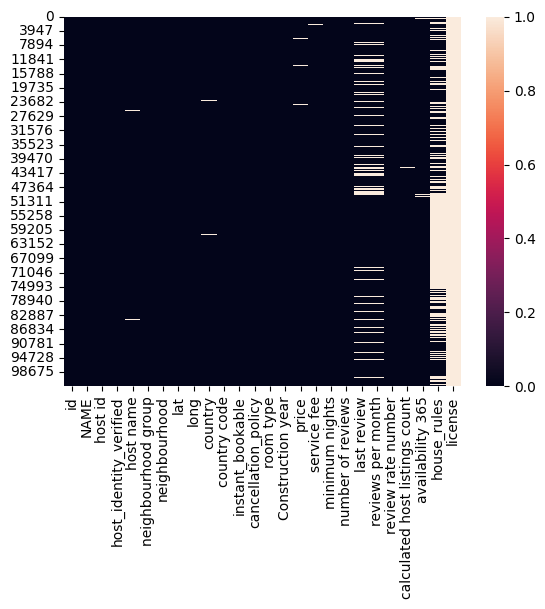

In [9]:
sns.heatmap(df.isnull())
plt.show()

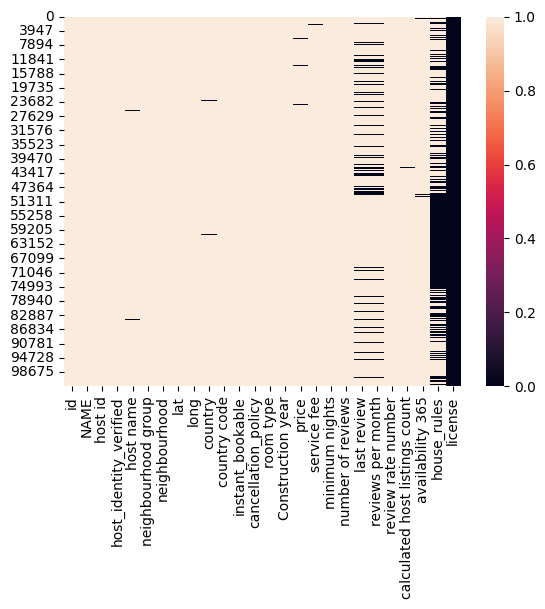

In [10]:
sns.heatmap(df.notnull())
plt.show()

In [11]:
df.drop(columns=["license"],inplace=True)

In [12]:
df.isnull().sum()

id                                    0
NAME                                250
host id                               0
host_identity_verified              289
host name                           406
neighbourhood group                  29
neighbourhood                        16
lat                                   8
long                                  8
country                             532
country code                        131
instant_bookable                    105
cancellation_policy                  76
room type                             0
Construction year                   214
price                               247
service fee                         273
minimum nights                      409
number of reviews                   183
last review                       15893
reviews per month                 15879
review rate number                  326
calculated host listings count      319
availability 365                    448
house_rules                       52131


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [14]:
mode_val = df["review rate number"].mode()

if not mode_val.empty:
    df["review rate number"] = df["review rate number"].fillna(mode_val[0])
else:
    print("Column is entirely empty; no mode found to fill with.")


In [15]:
df['lat'].fillna(df['lat'].median(), inplace=True)
df['long'].fillna(df['long'].median(), inplace=True)
df['Construction year'].fillna(df['Construction year'].median(), inplace=True)
df['minimum nights'].fillna(df['minimum nights'].median(), inplace=True)
df['number of reviews'].fillna(0, inplace=True)
df['reviews per month'].fillna(0, inplace=True)
df['calculated host listings count'].fillna(
    df['calculated host listings count'].median(),
    inplace=True
)
df['availability 365'].fillna(df['availability 365'].median(), inplace=True)

C:\Users\Midde Sravya\AppData\Local\Temp\ipykernel_29996\348392040.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['lat'].fillna(df['lat'].median(), inplace=True)
C:\Users\Midde Sravya\AppData\Local\Temp\ipykernel_29996\348392040.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [16]:
df.isnull().sum()

id                                    0
NAME                                250
host id                               0
host_identity_verified              289
host name                           406
neighbourhood group                  29
neighbourhood                        16
lat                                   0
long                                  0
country                             532
country code                        131
instant_bookable                    105
cancellation_policy                  76
room type                             0
Construction year                     0
price                               247
service fee                         273
minimum nights                        0
number of reviews                     0
last review                       15893
reviews per month                     0
review rate number                    0
calculated host listings count        0
availability 365                      0
house_rules                       52131


In [17]:
for i in df.select_dtypes(include="object").columns:
    mode_series = df[i].mode()
    if not mode_series.empty:
        df[i] = df[i].fillna(mode_series[0])


C:\Users\Midde Sravya\AppData\Local\Temp\ipykernel_29996\2104772343.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[i] = df[i].fillna(mode_series[0])


In [18]:
df.select_dtypes(include="float64").columns

Index(['lat', 'long', 'Construction year', 'minimum nights',
       'number of reviews', 'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102599 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102599 non-null  object 
 4   host name                       102599 non-null  object 
 5   neighbourhood group             102599 non-null  object 
 6   neighbourhood                   102599 non-null  object 
 7   lat                             102599 non-null  float64
 8   long                            102599 non-null  float64
 9   country                         102599 non-null  object 
 10  country code                    102599 non-null  object 
 11  instant_bookable                102599 non-null  bool   
 12  cancellation_pol

In [20]:
from sklearn.impute import SimpleImputer


In [21]:
si = SimpleImputer(strategy="mean")
ar=si.fit_transform(df[['lat', 'long', 'Construction year', 'minimum nights',
       'number of reviews', 'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365']])


In [22]:
new_df=pd.DataFrame(ar,columns=df.select_dtypes(include="float64").columns)

In [23]:
new_df

,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
0,40.64749,-73.97237,2020.0,10.0,9.0,0.21,4.0,6.0,286.0
1,40.75362,-73.98377,2007.0,30.0,45.0,0.38,4.0,2.0,228.0
2,40.80902,-73.94190,2005.0,3.0,0.0,0.00,5.0,1.0,352.0
3,40.68514,-73.95976,2005.0,30.0,270.0,4.64,4.0,1.0,322.0
4,40.79851,-73.94399,2009.0,10.0,9.0,0.10,3.0,1.0,289.0
...,...,...,...,...,...,...,...,...,...
102594,40.70862,-73.94651,2003.0,1.0,0.0,0.00,3.0,1.0,227.0
102595,40.80460,-73.96545,2016.0,1.0,1.0,0.02,2.0,2.0,395.0
102596,40.67505,-73.98045,2009.0,3.0,0.0,0.00,5.0,1.0,342.0
102597,40.74989,-73.93777,2015.0,2.0,5.0,0.10,3.0,1.0,386.0


In [24]:
df["lat"].mean()

np.float64(40.728093417823466)

In [25]:
df.select_dtypes(include=['object']).columns


Index(['NAME', 'host_identity_verified', 'host name', 'neighbourhood group',
       'neighbourhood', 'country', 'country code', 'cancellation_policy',
       'room type', 'price', 'service fee', 'last review', 'house_rules'],
      dtype='object')

In [26]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules'],
      dtype='object')

In [27]:
one_hot_columns = [
'host_identity_verified',
'instant_bookable',
'room type',
'neighbourhood group'
]

df = pd.get_dummies(df, columns=one_hot_columns, drop_first=True)

In [28]:
df.head()

,id,NAME,host id,host name,neighbourhood,lat,long,country,country code,cancellation_policy,...,instant_bookable_True,room type_Hotel room,room type_Private room,room type_Shared room,neighbourhood group_Brooklyn,neighbourhood group_Manhattan,neighbourhood group_Queens,neighbourhood group_Staten Island,neighbourhood group_brookln,neighbourhood group_manhatan
0,1001254,Clean & quiet apt home by the park,80014485718,Madaline,Kensington,40.64749,-73.97237,United States,US,strict,...,False,False,True,False,True,False,False,False,False,False
1,1002102,Skylit Midtown Castle,52335172823,Jenna,Midtown,40.75362,-73.98377,United States,US,moderate,...,False,False,False,False,False,True,False,False,False,False
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Elise,Harlem,40.80902,-73.94190,United States,US,flexible,...,True,False,True,False,False,True,False,False,False,False
3,1002755,Home away from home,85098326012,Garry,Clinton Hill,40.68514,-73.95976,United States,US,moderate,...,True,False,False,False,True,False,False,False,False,False
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,Lyndon,East Harlem,40.79851,-73.94399,United States,US,moderate,...,False,False,False,False,False,True,False,False,False,False


In [29]:
df.columns

Index(['id', 'NAME', 'host id', 'host name', 'neighbourhood', 'lat', 'long',
       'country', 'country code', 'cancellation_policy', 'Construction year',
       'price', 'service fee', 'minimum nights', 'number of reviews',
       'last review', 'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365', 'house_rules',
       'host_identity_verified_verified', 'instant_bookable_True',
       'room type_Hotel room', 'room type_Private room',
       'room type_Shared room', 'neighbourhood group_Brooklyn',
       'neighbourhood group_Manhattan', 'neighbourhood group_Queens',
       'neighbourhood group_Staten Island', 'neighbourhood group_brookln',
       'neighbourhood group_manhatan'],
      dtype='object')

In [30]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [31]:
df['neighbourhood'] = encoder.fit_transform(df['neighbourhood'])

In [32]:
df[['neighbourhood']].head()

,neighbourhood
0,111
1,130
2,97
3,42
4,62


In [33]:
df['neighbourhood'].nunique()

224

In [34]:
df.shape

(102599, 32)

In [35]:
df['cancellation_policy'].unique()

array(['strict', 'moderate', 'flexible'], dtype=object)

In [36]:
df.columns

Index(['id', 'NAME', 'host id', 'host name', 'neighbourhood', 'lat', 'long',
       'country', 'country code', 'cancellation_policy', 'Construction year',
       'price', 'service fee', 'minimum nights', 'number of reviews',
       'last review', 'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365', 'house_rules',
       'host_identity_verified_verified', 'instant_bookable_True',
       'room type_Hotel room', 'room type_Private room',
       'room type_Shared room', 'neighbourhood group_Brooklyn',
       'neighbourhood group_Manhattan', 'neighbourhood group_Queens',
       'neighbourhood group_Staten Island', 'neighbourhood group_brookln',
       'neighbourhood group_manhatan'],
      dtype='object')

In [37]:
cols_to_drop = [
'id',
'NAME',
'host id',
'host name',
'country',
'country code',
'last review',
'house_rules'
]

df.drop(columns=cols_to_drop, inplace=True,errors='ignore')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   neighbourhood                      102599 non-null  int64  
 1   lat                                102599 non-null  float64
 2   long                               102599 non-null  float64
 3   cancellation_policy                102599 non-null  object 
 4   Construction year                  102599 non-null  float64
 5   price                              102599 non-null  object 
 6   service fee                        102599 non-null  object 
 7   minimum nights                     102599 non-null  float64
 8   number of reviews                  102599 non-null  float64
 9   reviews per month                  102599 non-null  float64
 10  review rate number                 102599 non-null  float64
 11  calculated host listings count     1025

In [39]:
df[['neighbourhood group_Brooklyn','neighbourhood group_brookln']].head()

,neighbourhood group_Brooklyn,neighbourhood group_brookln
0,True,False
1,False,False
2,False,False
3,True,False
4,False,False


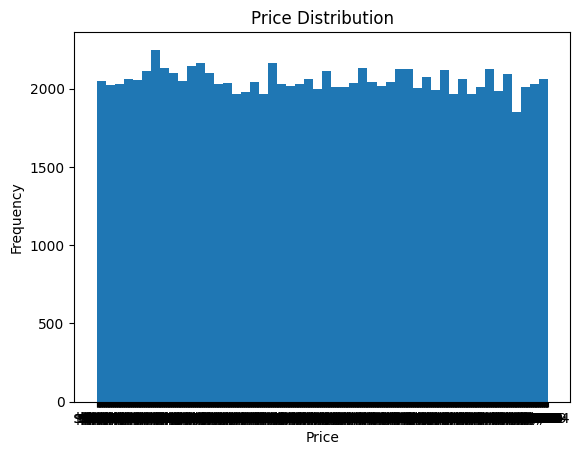

In [40]:
import matplotlib.pyplot as plt

plt.hist(df['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

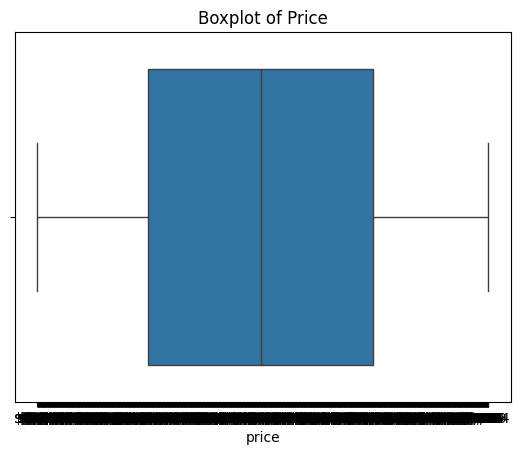

In [41]:
import seaborn as sns

sns.boxplot(x=df['price'])
plt.title("Boxplot of Price")
plt.show()

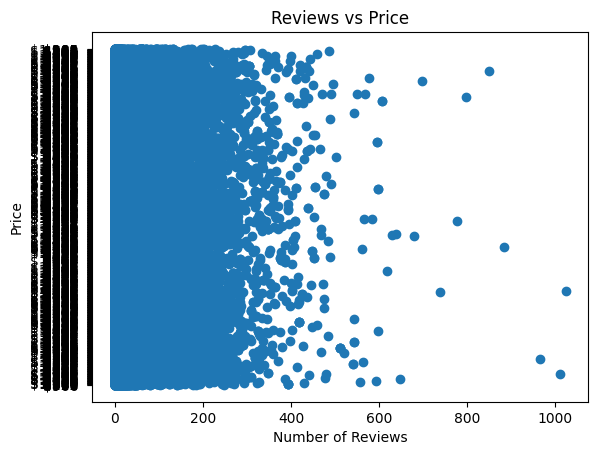

In [42]:
plt.scatter(df['number of reviews'], df['price'])
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.title("Reviews vs Price")
plt.show()

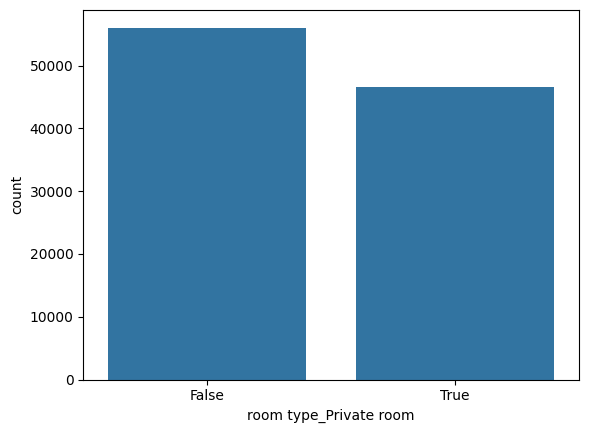

In [43]:
sns.countplot(x='room type_Private room', data=df)
plt.show()

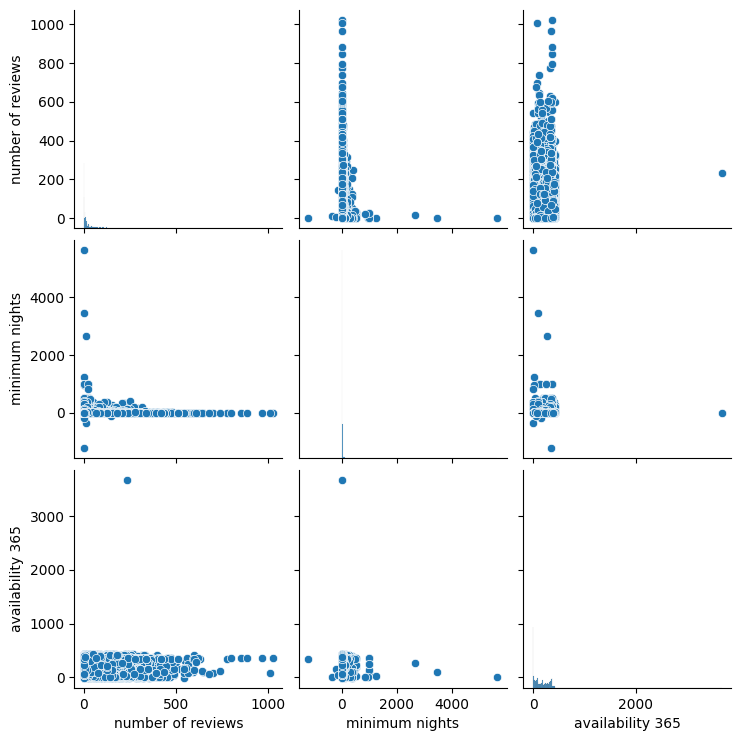

In [44]:
sns.pairplot(df[['price','number of reviews','minimum nights','availability 365']])
plt.show()

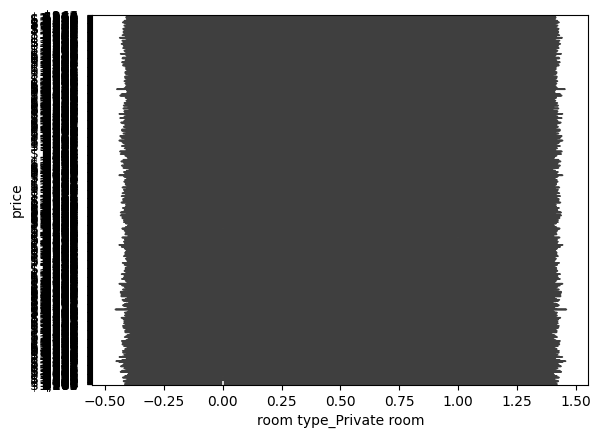

In [45]:
sns.violinplot(x='room type_Private room', y='price', data=df)
plt.show()

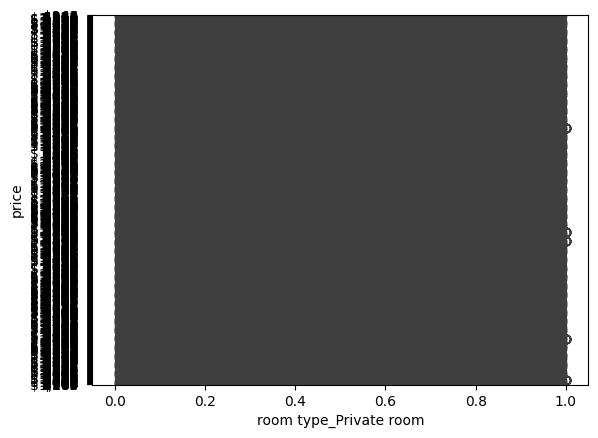

In [46]:
sns.boxplot(x=df['room type_Private room'], y=df['price'])
plt.show()

In [47]:
df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)

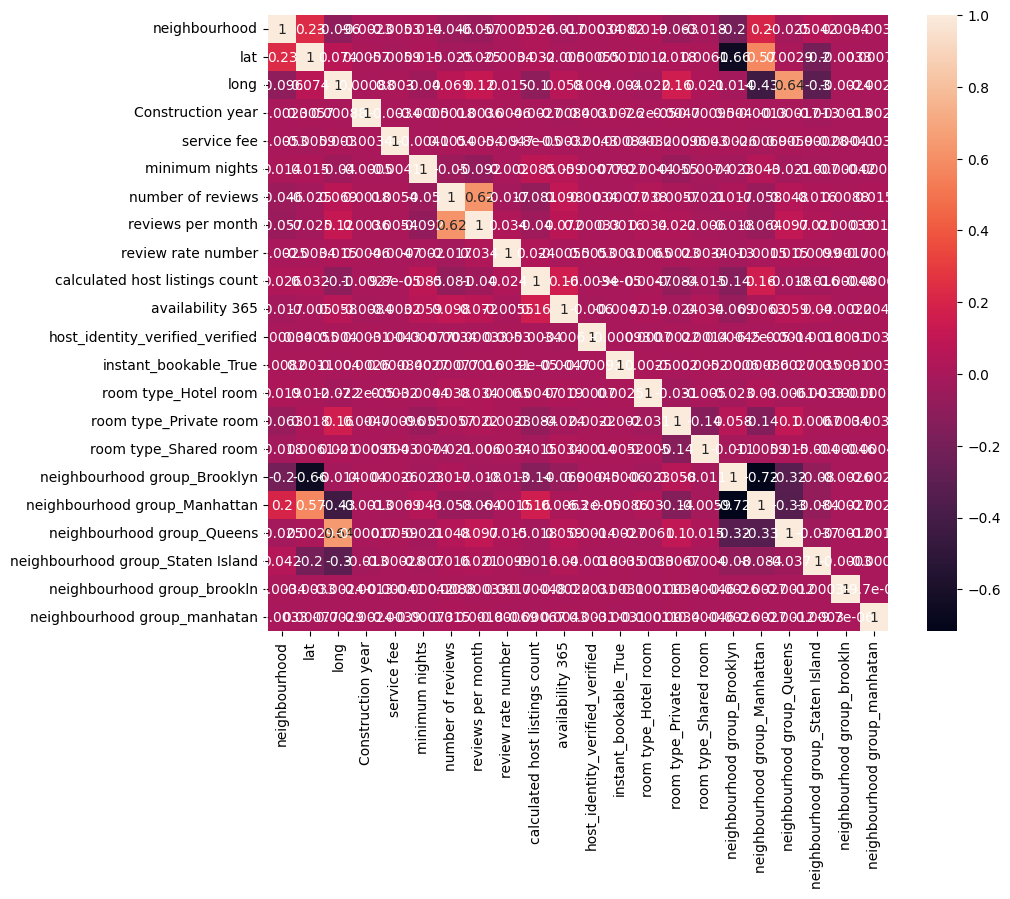

In [48]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [49]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   neighbourhood                      102599 non-null  int64  
 1   lat                                102599 non-null  float64
 2   long                               102599 non-null  float64
 3   cancellation_policy                102599 non-null  object 
 4   Construction year                  102599 non-null  float64
 5   price                              102599 non-null  object 
 6   service fee                        102599 non-null  float64
 7   minimum nights                     102599 non-null  float64
 8   number of reviews                  102599 non-null  float64
 9   reviews per month                  102599 non-null  float64
 10  review rate number                 102599 non-null  float64
 11  calculated host listings count     1025

In [51]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

In [52]:
df['price'].dtype


dtype('float64')

In [53]:
df['cancellation_policy'].unique()

array(['strict', 'moderate', 'flexible'], dtype=object)

In [54]:
df['cancellation_policy'] = df['cancellation_policy'].map({
    'flexible':0,
    'moderate':1,
    'strict':2
}) 
df['cancellation_policy'].dtype

dtype('int64')

In [55]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4.2334851508538645
MSE: 1560.3713481915497
RMSE: 39.50153602319218
R2 Score: 0.9857614363571745


In [58]:
lr_model.coef_

array([-2.41071325e-03,  6.29636336e+00,  2.77488371e+00, -1.16896241e-01,
       -1.17658525e-02,  4.97224247e+00, -1.09939169e-03, -5.32339214e-03,
        1.59953015e-01,  1.70213970e-02, -6.34554035e-03,  1.00724695e-03,
       -2.65716437e-01, -3.30758381e-01,  1.54826347e+01, -1.73384289e-01,
       -1.99908060e+00,  1.66196195e+00,  6.70345701e-01,  4.86800370e-01,
        2.16497723e+00,  2.36493272e+00,  2.54212573e+02])

In [59]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)
y_pred_tree = dt_model.predict(X_test)
print("R2:", r2_score(y_test, y_pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))

R2: 0.9793425772028135
RMSE: 47.57940014059437


In [62]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [63]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2: 0.9874057575213999
RMSE: 37.15069292020653


In [64]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10)

service fee                       0.990370
long                              0.001572
lat                               0.001431
availability 365                  0.001109
reviews per month                 0.000924
number of reviews                 0.000788
neighbourhood                     0.000777
minimum nights                    0.000620
Construction year                 0.000575
calculated host listings count    0.000553
dtype: float64

In [65]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 3.7 MB/s eta 0:00:27
    --------------------------------------- 2.1/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 2.9/101.7 MB 4.1 MB/s eta 0:00:25
   - -------------------------------------- 3.7/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 4.2/101.7 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 4.7/101.7 MB 3.5 MB/s eta 0:00:28
   - -------------------------------------- 5.0/101.7 MB 3.5 MB/s eta 0:00:28
   -- ------------------------------------- 5.5/101.7 MB 3.2 MB/s eta 0:00:31
   -- ------------------------------------- 5.8/101.7 MB 3.0 MB/s eta 0:00:32
   -- ------------------------------------- 5.8/101.7 MB 3.0 MB/s eta 0:00:32


In [66]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [67]:
y_pred_xgb = xgb_model.predict(X_test)
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

R2: 0.9876612840132059
RMSE: 36.771883628521444


In [68]:
import pandas as pd

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10)

service fee                        0.938887
neighbourhood group_Queens         0.026268
neighbourhood group_Brooklyn       0.004346
room type_Hotel room               0.003475
cancellation_policy                0.003405
host_identity_verified_verified    0.002413
reviews per month                  0.002389
availability 365                   0.002319
long                               0.001929
neighbourhood                      0.001886
dtype: float32

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 4.90670729371307
RMSE: 36.771883628521444
R2: 0.9876612840132059


In [70]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", scores)
print("Average R2:", scores.mean())

Cross Validation Scores: [0.98641942 0.98926515 0.99631342 0.97925817 0.99456866]
Average R2: 0.9891649645407854


In [71]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best Score: 0.9901427273009114
